In [1]:
'''
＜解析の流れ＞　(（）は今回は省略した行程)

ダミー変数化
テストデータの分離

欠損値の補完・削除
xとyへの分割
外れ値の除外
（標準化）
教師データの分割

訓練データで学習
検証データで評価

(特徴量の絞り込み)
多項式特徴量の追加
交互作用特徴量の追加

テストデータで最終評価
'''

'\n＜解析の流れ＞\u3000(（）は今回は省略した行程)\n\nダミー変数化\nテストデータの分離\n\n欠損値の補完・削除\nxとyへの分割\n外れ値の除外\n（標準化）\n教師データの分割\n\n訓練データで学習\n検証データで評価\n\n(特徴量の絞り込み)\n多項式特徴量の追加\n交互作用特徴量の追加\n\nテストデータで最終評価\n'

In [2]:
#import
import pandas as pd

from sklearn.model_selection import train_test_split  #データの分割
from sklearn.covariance import MinCovDet  #マハラノビス距離

from sklearn.tree import DecisionTreeClassifier  #決定木（標準化は不要）
from sklearn.preprocessing import PolynomialFeatures  #交互作用特徴量

from sklearn.linear_model import Ridge  #リッジ回帰

In [3]:
#データの前処理
df=pd.read_csv('sukkiri-ml-codes (1)\datafiles\Bank.csv')
df.head(5)


,id,age,job,marital,education,default,amount,housing,loan,contact,day,month,duration,campaign,previous,y
0,1,39,blue-collar,married,secondary,no,1756.0,yes,no,cellular,3,apr,370.055237,1,0,1
1,2,51,entrepreneur,married,primary,no,1443.0,no,no,cellular,18,feb,233.998933,10,0,1
2,3,36,management,single,tertiary,no,436.0,no,no,cellular,13,apr,NaN,1,2,0
3,4,63,retired,married,secondary,no,474.0,no,no,cellular,25,jan,252.525808,1,0,0
4,5,31,management,single,tertiary,no,354.0,no,no,cellular,30,apr,NaN,1,2,0


In [4]:
#ダミー変数化
str_col_name=['job','default','marital','education','housing','loan','contact','month']
str_df = df[str_col_name]  #文字列を抜き出す
str_df2=pd.get_dummies(str_df,drop_first=True)  #複数列を一気にダミー変数化

num_df = df.drop(str_col_name,axis=1)  #数値列を抜き出す
df2 = pd.concat([num_df,str_df2,],axis=1)  #結合


#不要な特徴量の削除
df2=df2.drop('id',axis=1)

欠損値補完

In [5]:
#欠損値補完
print(df2.isnull().sum())

age                             0
amount                          0
day                             0
duration                     7044
campaign                        0
previous                        0
y                               0
job_blue-collar                 0
job_entrepreneur                0
job_housemaid                   0
job_management                  0
job_retired                     0
job_self-employed               0
job_services                    0
job_student                     0
job_technician                  0
job_unemployed                  0
job_unknown                     0
default_yes                     0
marital_married                 0
marital_single                  0
education_secondary             0
education_tertiary              0
education_unknown               0
housing_yes                     0
loan_yes                        0
contact_sending _document       0
contact_telephone               0
month_aug                       0
month_dec     

In [6]:
#durationに多くの欠損値があるので補完する

#リッジ回帰でのdurationの予測モデル
x_ridge_cols=[c for c in df2.columns if c != 'duration']
y_ridge_cols=['duration']

#df3は欠損値なし、df4は欠損値ありのデータフレームとして分ける
df3=df2[df2['duration'].notna()]
df4=df2[df2['duration'].isna()]

#リッジ回帰用の訓練データと検証データに分割
train,val = train_test_split(df3,test_size=0.1,random_state=0)

#正則化項の定数を0.01~20まで検証
best_ridgescore=0
best_alpha=0
for i in range(1,2001):
    ridgeModel=Ridge(alpha=(i/100))
    ridgeModel.fit(train[x_ridge_cols],train[y_ridge_cols])
    ridgescore=ridgeModel.score(val[x_ridge_cols],val[y_ridge_cols])
    if best_ridgescore < ridgescore:
        best_ridgescore=ridgescore
        best_alpha=i
print(f'正則化項＝{best_alpha}　リッジ回帰のスコア＝{best_ridgescore}')

正則化項＝1608　リッジ回帰のスコア＝0.8177174379172119


In [7]:
#完成したリッジ回帰モデルで欠損値補完
final_ridgeModel=Ridge(alpha=(best_alpha/100))
final_ridgeModel.fit(train[x_ridge_cols],train[y_ridge_cols])
ex_y=final_ridgeModel.predict(df4[x_ridge_cols])
df4['duration']=ex_y
print(f'durationの予測値は{ex_y}')

#欠損値を補完した df5 を学習データとして使用する。
df5=pd.concat([df3,df4],axis=0)

durationの予測値は[171.9169832  152.95338195 160.51022445 ... 216.9442113  337.76002583
 345.84805489]


C:\Users\natsu\AppData\Local\Temp\ipykernel_21140\3540192415.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df4['duration']=ex_y


データの分割、学習・検証データにおける外れ値の削除

In [8]:
#x,y列の指定
y_cols=['y']
x_cols=[c for c in df5.columns if c!='y']

#訓練&検証データとテストデータに分割
train_val,test = train_test_split(df5,test_size=0.1,random_state=0)

In [9]:
print(train_val.columns)
print()
print(train_val.dtypes)

Index(['age', 'amount', 'day', 'duration', 'campaign', 'previous', 'y',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'default_yes', 'marital_married', 'marital_single',
       'education_secondary', 'education_tertiary', 'education_unknown',
       'housing_yes', 'loan_yes', 'contact_sending _document',
       'contact_telephone', 'month_aug', 'month_dec', 'month_feb', 'month_jan',
       'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov',
       'month_oct', 'month_sep'],
      dtype='object')

age                            int64
amount                       float64
day                            int64
duration                     float64
campaign                       int64
previous                       int64
y                              int64
job_blue-collar                 bool
job_entrepreneu

<Axes: >

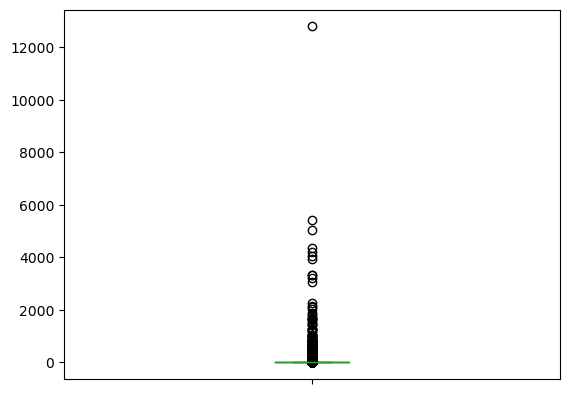

In [10]:
#マハラノビス距離を求める
#train_val全体でやるとLinAlgErrorになったので、今回はダミー変数を除く
mcd2 =MinCovDet(random_state=0,support_fraction=0.7)
num_train_val_name = ['age', 'amount', 'day', 'duration', 'campaign', 'previous', 'y'] #数値列を抜き出す
num_train_val=train_val[num_train_val_name]

mcd2.fit(num_train_val) 
dis = pd.Series(
    mcd2.mahalanobis(num_train_val),
    index=train_val.index
)
dis=pd.Series(dis)

#箱ひげ図を描く
dis.plot(kind="box")

<Axes: >

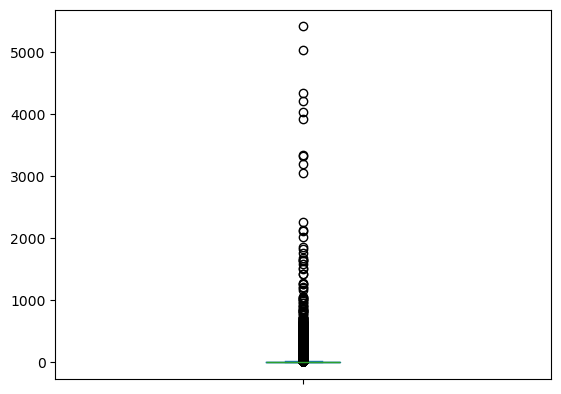

In [11]:
#外れ値の削除
no=dis[dis>12000].index
train_val = train_val.drop(no)

num_train_val=train_val[num_train_val_name]
mcd2.fit(num_train_val) 
dis2 =mcd2.mahalanobis(num_train_val)
dis2=pd.Series(dis2)
dis2.plot(kind="box")

In [12]:
#訓練データと検証データに分割
x_train,x_val,y_train,y_val = train_test_split(train_val[x_cols],train_val[y_cols],test_size=0.2,random_state=0)

決定木

In [13]:
#学習
best_depth=0
best_score=0
for i in range(1,21):
    model=DecisionTreeClassifier(max_depth=i,random_state=0,class_weight='balanced')  #不均衡データに配慮
    model.fit(x_train,y_train)
    score=model.score(x_val,y_val)
    print(f'決定木の深さ={i}  検証データでのスコア={score}')
    if best_score < score :
        best_depth=i
        best_score=score

print(f'完成したモデルの決定木の深さ={best_depth}  検証データでのスコア={best_score}')
final_model=DecisionTreeClassifier(max_depth=best_depth,random_state=0,class_weight='balanced')

決定木の深さ=1  検証データでのスコア=0.7575261109973377
決定木の深さ=2  検証データでのスコア=0.7575261109973377
決定木の深さ=3  検証データでのスコア=0.7012082736022937
決定木の深さ=4  検証データでのスコア=0.754044644685644
決定木の深さ=5  検証データでのスコア=0.7661273807085808
決定木の深さ=6  検証データでのスコア=0.7956174482899857
決定木の深さ=7  検証データでのスコア=0.8152774933442556
決定木の深さ=8  検証データでのスコア=0.8169158304321114
決定木の深さ=9  検証データでのスコア=0.8199877124718411
決定木の深さ=10  検証データでのスコア=0.8183493753839852
決定木の深さ=11  検証データでのスコア=0.8210116731517509
決定木の深さ=12  検証データでのスコア=0.8154822854802376
決定木の深さ=13  検証データでのスコア=0.8077001843129223
決定木の深さ=14  検証データでのスコア=0.8085193528568503
決定木の深さ=15  検証データでのスコア=0.8025803809133729
決定木の深さ=16  検証データでのスコア=0.7952078640180217
決定木の深さ=17  検証データでのスコア=0.7982797460577514
決定木の深さ=18  検証データでのスコア=0.7986893303297153
決定木の深さ=19  検証データでのスコア=0.8009420438255171
決定木の深さ=20  検証データでのスコア=0.7976653696498055
完成したモデルの決定木の深さ=11  検証データでのスコア=0.8210116731517509


In [ ]:
#多項式特徴量の導入

#指数を1~5まで変えて、自動的に実験。内側のループが完了後、多項式特徴量を導入して次のループへ
for c in x_train.columns:
    best_exponent=0
    best_score=0
    for i in range(1,6):
        x_train2=x_train.copy()
        x_train2[c]=x_train2[c]**i
        x_val2=x_val.copy()
        x_val2[c]=x_val2[c]**i

        final_model.fit(x_train2,y_train)
        score=final_model.score(x_val2,y_val)

        if best_score < score:
            best_exponent=i
            best_score=score

    if best_exponent!=1:  #１以外の指数が最適ならば累乗する
        col_name=c+i
        x_train[col_name]=x_train[c]**best_exponent
        x_train=x_train.drop(c,axis=1)
        x_val[col_name]=x_val[c]**best_exponent
        x_val=x_val.drop(c,axis=1)
        test[col_name]=test[c]**best_exponent  #テストデータでも特徴量を変更
        test=test.drop(c,axis=1)      
        print(f'導入した列＝{c}  指数＝{best_exponent}  導入後のスコア＝{best_score}')

導入した列＝amount  指数＝4  導入後のスコア＝0.8216260495596969


In [15]:
#交互作用特徴量の導入
x_cols2=x_train.columns  #導入する交互作用特徴量は２次とする
for c1 in x_cols2:
    best_exponent=0
    best_score=0
    for c2 in x_cols2:
        if c1==c2:
            continue
        else:
            col_name=c1+'×'+c2
            x_train3=x_train.copy()
            x_train3[col_name]=x_train[c1]*x_train[c2]
            x_val3=x_val.copy()
            x_val3[col_name]=x_val[c1]*x_val[c2]

            final_model.fit(x_train,y_train)
            prescore=final_model.score(x_val,y_val)  #導入前のスコア
            final_model.fit(x_train3,y_train)
            score=final_model.score(x_val3,y_val)  #導入後のスコア

            if prescore < score:
                x_train[col_name]=x_train[c1]*x_train[c2]
                x_val[col_name]=x_val[c1]*x_val[c2]
                test[col_name]=test[c1]*test[c2]  #テストデータでも特徴量を変更

print(f'追加した多項式特徴量・交互作用特徴量は {set(x_train.columns)-set(x_cols)}')

追加した多項式特徴量・交互作用特徴量は {'age×month_may', 'age×month_dec', 'age×month_nov', 'job_blue-collar×default_yes', 'default_yes×marital_married', 'age×amount2', 'age×marital_married', 'age×job_technician', 'previous×job_self-employed', 'previous×job_technician', 'job_blue-collar×month_aug', 'age×job_blue-collar', 'job_self-employed×previous', 'job_blue-collar×day', 'age×day', 'amount2', 'day×job_management', 'day×month_feb', 'age×campaign'}


In [16]:
final_x_cols=x_train.columns

In [17]:
#完成したモデルをテストデータで評価
final_model.fit(x_train[final_x_cols],y_train[y_cols])
score=final_model.score(test[final_x_cols],test[y_cols])
print(f'テストデータでのスコアは{score}')

テストデータでのスコアは0.8297088094360486
